In [7]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp

In [8]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [9]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

FREQ_RANGE = [250, 350]

In [15]:
data1.keys()

dict_keys(['__header__', '__version__', '__globals__', 'mode_nos', 'peaks_coordinates'])

In [12]:
data1 = scipy.io.loadmat("../mode_arrival_times.mat")
replicas = scipy.io.loadmat("../data/field_values20260707/field_values20260707.mat")
data1['mode_nos'] = data1['mode_nos'] - 1

f = replicas['f'].squeeze()
f_Vg = f[1:-1]
c = replicas['soundspeed'].squeeze()
Vg = replicas['Vg'].squeeze()
Vg = Vg[data1['mode_nos'].squeeze()]
receiver_range = replicas['range'][0,0]*1e3

nmodes, nspeed, nfreq = Vg.shape

In [218]:
data1['peaks_coordinates'] = [ M for M in data1['peaks_coordinates'][0]]

In [219]:
f_mask = np.array([f_Vg >= FREQ_RANGE[0],f_Vg <= FREQ_RANGE[1]]).all(0)
regression_f = f_Vg[f_mask]

In [220]:
coefs = np.array([np.polyfit(d[:,1], d[:,0], 2) for d in data1['peaks_coordinates']])
arrival_times_data = np.array([np.polyval(c, regression_f) for c in coefs])

(6.65, 7.75)

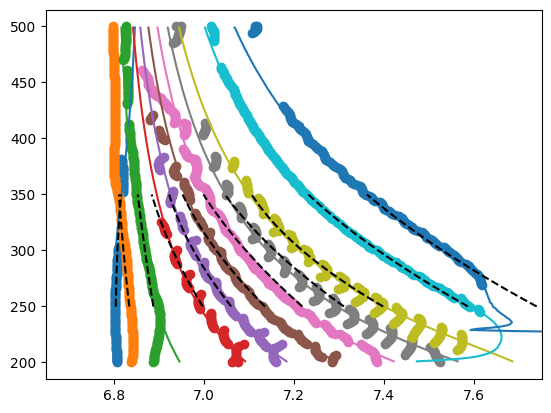

In [222]:
fig, ax = plt.subplots()

for p in data1['peaks_coordinates']:
    ax.scatter(p[:,0], p[:,1])
    
ax.plot(receiver_range/Vg[:, c==TRUE_SOUNDSPEED,:].squeeze().T, f_Vg)
ax.set_prop_cycle(None)
ax.plot(arrival_times_data.T, regression_f, ls='--', c='k')


ax.set_xlim([6.65, 7.75])

In [223]:
#arrival_times_data = receiver_range/Vg[:, c == TRUE_SOUNDSPEED, ...]
arrival_times_replica = receiver_range/Vg[...,f_mask]

## Direct dispersion

In [224]:
residuals_direct = arrival_times_data - arrival_times_replica.transpose([1,0,2])

In [225]:
likelihood_direct = np.exp(-np.sum(np.linalg.norm(residuals_direct, 2,2)**2,1))

Text(0, 0.5, 'Likelihood')

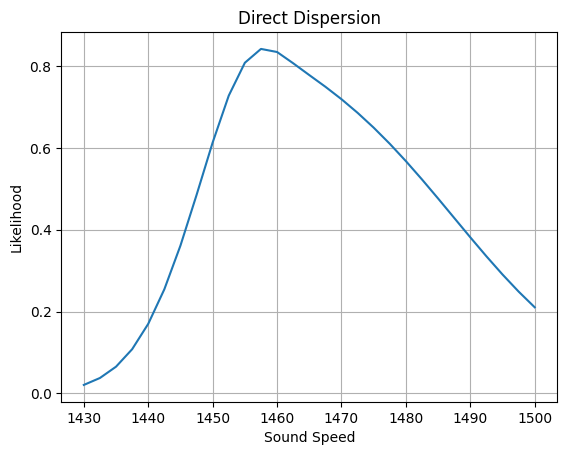

In [226]:
fig, ax = plt.subplots()

ax.plot(c, likelihood_direct)
ax.grid()


ax.set_title(f'Direct Dispersion')
ax.set_xlabel('Sound Speed')
ax.set_ylabel('Likelihood')

In [227]:
fig.savefig('Direct Dispersion Spectrogram.png', dpi=600)

## Intramodal dispersion

In [228]:
residual_intramodal = np.zeros((nspeed, nmodes, nfreq, nfreq))

for indmode in range(nmodes):
    delta_data = arrival_times_data[indmode,...] - arrival_times_data[indmode, :, np.newaxis]
    for indc in range(nspeed): 
        delta_replica = arrival_times_replica[indmode, indc] - arrival_times_replica[indmode, indc, :, np.newaxis]
        residual_intramodal[indc, indmode, ...] = np.abs(delta_data - delta_replica)**2
        
likelihood_intramodal = np.exp(-np.linalg.norm(residual_intramodal,2,1))

ValueError: could not broadcast input array from shape (101,101) into shape (299,299)

In [ ]:
soundspeed_est_intramodal = c[np.argmax(likelihood_intramodal, 0)]

fig = plt.figure(layout='constrained')

for imode in range(nmodes):
    row, col = np.unravel_index(imode, (4,5))
    ax = fig.add_subplot(4,5,imode+1)
    ax.pcolormesh(regression_f, regression_f, np.abs(soundspeed_est_intramodal[imode] - TRUE_SOUNDSPEED))
    #ax.pcolormesh(f_Vg, f_Vg, likelihood_intramodal[imode])
    ax.set_title(f'Mode {imode+1}')

fig.set_size_inches([10, 8])

In [ ]:
fig, ax = plt.subplots()

ax.plot(c, likelihood_intramodal[:,regression_f==280, regression_f==320])

ax.set_title(f'Intramodal dispersion f1 = 280Hz, f2 = 320')
ax.set_xlabel('Sound Speed')
ax.set_ylabel('Likelihood')

ax.grid()

In [ ]:
fig.savefig('Intramodal Dispersion Spectrogram.png', dpi=600)

## Intermodal dispersion

In [ ]:
residual_intermodal = np.zeros((nspeed, nfreq, nmodes, nmodes))

for indfreq in range(nfreq):
    delta_data = arrival_times_data[...,indfreq] - arrival_times_data[...,indfreq,np.newaxis]
    for indc in range(nspeed): 
        delta_replica = arrival_times_replica[:, indc, indfreq] - arrival_times_replica[:, np.newaxis, indc, indfreq]
        residual_intermodal[indc, indfreq, ...] = np.abs(delta_data - delta_replica)**2
        
likelihood_intermodal = np.exp(-np.linalg.norm(residual_intermodal,2,1)**2/1e-7)

In [ ]:
fig = plt.figure(layout='constrained')

for ir in range(4):
    for ic in range(ir+1):
        ax = fig.add_subplot(4,4, 4*ir + ic +1)
        l1 = ax.plot(c, likelihood_intermodal[:, ir+1, ic])

        ax.set_title(f'Modes {ic+1} and {ir+2}')

fig.legend(l1, regression_f[::20])
fig.set_size_inches([20,10])
fig.supxlabel('Sound Speed (m/s)')
fig.supylabel('Likelihood ($\\exp (-e_2/\\sigma)$)')

In [ ]:
fig.savefig('Likelihood Intermodal Spectrogram.png', dpi=600)